#📌 Extracão

In [ ]:
import pandas as pd
url= "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"
df = pd.read_json(url)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformação

Dicionário de dados

customerID: número de identificação único de cada clienTE

Churn: se o cliente deixou ou não a empresa

gender: gênero (masculino e feminino)

SeniorCitizen: informação sobre um cliente ter ou não idade igual ou maior que 65 anos

Partner: se o cliente possui ou não um parceiro ou parceira

Dependents: se o cliente possui ou não dependentes

tenure: meses de contrato do cliente

PhoneService: assinatura de serviço telefônico

MultipleLines: assisnatura de mais de uma linha de telefone

InternetService: assinatura de um provedor internet

OnlineSecurity: assinatura adicional de segurança online

OnlineBackup: assinatura adicional de backup online

DeviceProtection: assinatura adicional de proteção no dispositivo

TechSupport: assinatura adicional de suporte técnico, menos tempo de espera

StreamingTV: assinatura de TV a cabo

StreamingMovies: assinatura de streaming de filmes

Contract: tipo de contrato

PaperlessBilling: se o cliente prefere receber online a fatura

PaymentMethod: forma de pagamento

Charges.Monthly: total de todos os serviços do cliente por mês

Charges.Total: total gasto pelo cliente

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [ ]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [ ]:
print(df.columns)

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')


In [ ]:
dfaux = df["customer"].apply(pd.Series)
df = pd.concat([df.drop("customer", axis=1), dfaux], axis=1)

In [ ]:
dfaux = df["phone"].apply(pd.Series)
df = pd.concat([df.drop("phone", axis=1), dfaux], axis=1)

In [ ]:
dfaux = df["internet"].apply(pd.Series)
df = pd.concat([df.drop("internet", axis=1), dfaux], axis=1)

In [ ]:
dfaux = df["account"].apply(pd.Series)
df = pd.concat([df.drop("account", axis=1), dfaux], axis=1)

In [ ]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,"{'Monthly': 65.6, 'Total': '593.3'}"
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,"{'Monthly': 59.9, 'Total': '542.4'}"
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,"{'Monthly': 73.9, 'Total': '280.85'}"
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,"{'Monthly': 98.0, 'Total': '1237.85'}"
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,"{'Monthly': 83.9, 'Total': '267.4'}"


In [ ]:
dfaux = df["Charges"].apply(pd.Series)
df = pd.concat([df.drop("Charges", axis=1), dfaux], axis=1)

In [ ]:
for col in df.columns:
    print(col, pd.unique(df[col]))

customerID ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn ['No' 'Yes' '']
gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['Yes' 'No']
tenure [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
PhoneService ['Yes' 'No']
MultipleLines ['No' 'Yes' 'No phone service']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['Yes' 'No' 'No internet service']
StreamingTV ['Yes' 'No' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['One year' 'Month-to-month' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Mailed check' 'Electronic check' 'Credit card (automati

In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df.isnull().sum())

customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Monthly             0
Total               0
dtype: int64


In [ ]:
print((df == "").sum())

customerID            0
Churn               224
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
Monthly               0
Total                 0
dtype: int64


In [ ]:
len(df)

7267

In [ ]:
df["Churn"] = df["Churn"].replace("", pd.NA)

In [ ]:
df = df.dropna(subset=["Churn"])
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
print(df.isnull().sum())

customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Monthly             0
Total               0
dtype: int64


In [ ]:
len(df)

7043

In [ ]:
df = df.drop("customerID", axis=1)
df.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

In [ ]:
print(df.dtypes)

Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Monthly             float64
Total                object
dtype: object


In [ ]:
df['Total'] = df['Total'].replace('', '0')
df['Total'] = df['Total'].astype(float)

In [ ]:
cols_no_service = ['MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for col in cols_no_service:
    df[col] = df[col].replace({'No internet service':'No', 'No phone service':'No'})

In [ ]:
for col in df.columns:
    print(col, pd.unique(df[col]))

Churn ['No' 'Yes']
gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['Yes' 'No']
tenure [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42
  0]
PhoneService ['Yes' 'No']
MultipleLines ['No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes']
OnlineBackup ['Yes' 'No']
DeviceProtection ['No' 'Yes']
TechSupport ['Yes' 'No']
StreamingTV ['Yes' 'No']
StreamingMovies ['No' 'Yes']
Contract ['One year' 'Month-to-month' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
Monthly [65.6  59.9  73.9  ... 91.75 68.8  67.85]
Total [ 593.3   542.4   280.85 ...  742.9  4627.65 3707.6 ]


In [ ]:
df['Contas_Diarias'] = (df['Monthly'] / 30).round(2)
df.head()


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,Contas_Diarias
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


In [ ]:
df.rename(columns={

    'Churn': 'Evasao',
    'gender': 'Genero',
    'SeniorCitizen': 'Idoso',
    'Partner': 'Parceiro',
    'Dependents': 'Dependentes',
    'tenure': 'Meses_Contrato',
    'PhoneService': 'Servico_Telefonico',
    'MultipleLines': 'Mais_de_uma_Linha',
    'InternetService': 'Provedor_Internet',
    'OnlineSecurity': 'Seguranca_Online',
    'OnlineBackup': 'Backup_Online',
    'DeviceProtection': 'Protecao_Dispositivo',
    'TechSupport': 'Suporte_Tecnico',
    'StreamingTV': 'TV',
    'StreamingMovies': 'Streaming_Filmes',
    'Contract': 'Contrato',
    'PaperlessBilling': 'Fatura_Online',
    'PaymentMethod': 'Forma_Pagamento',
    'Monthly': 'Pagamento_Mensal',
    'Total': 'Pagamento_Total'
}, inplace=True)
df.head()

,Evasao,Genero,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefonico,Mais_de_uma_Linha,Provedor_Internet,Seguranca_Online,...,Protecao_Dispositivo,Suporte_Tecnico,TV,Streaming_Filmes,Contrato,Fatura_Online,Forma_Pagamento,Pagamento_Mensal,Pagamento_Total,Contas_Diarias
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


In [ ]:
map_yes_no = {'Yes': 1, 'No': 0}

cols_to_binary = ['Evasao', 'Parceiro', 'Dependentes', 'Servico_Telefonico',
                  'Mais_de_uma_Linha', 'Seguranca_Online', 'Backup_Online',
                  'Protecao_Dispositivo', 'Suporte_Tecnico', 'TV', 'Streaming_Filmes',
                  'Fatura_Online']

for col in cols_to_binary:
    df[col] = df[col].map(map_yes_no)

In [ ]:
for col in df.columns:
    print(col, pd.unique(df[col]))

Evasao [0 1]
Genero ['Female' 'Male']
Idoso [0 1]
Parceiro [1 0]
Dependentes [1 0]
Meses_Contrato [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42
  0]
Servico_Telefonico [1 0]
Mais_de_uma_Linha [0 1]
Provedor_Internet ['DSL' 'Fiber optic' 'No']
Seguranca_Online [0 1]
Backup_Online [1 0]
Protecao_Dispositivo [0 1]
Suporte_Tecnico [1 0]
TV [1 0]
Streaming_Filmes [0 1]
Contrato ['One year' 'Month-to-month' 'Two year']
Fatura_Online [1 0]
Forma_Pagamento ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
Pagamento_Mensal [65.6  59.9  73.9  ... 91.75 68.8  67.85]
Pagamento_Total [ 593.3   542.4   280.85 ...  742.9  4627.65 3707.6 ]
Contas_Diarias [2.19 2.   2.46 3.27 2.8  2.31 3.66 2.82 1.61 3.02 1.51 3.89 2.3  3.38
 1.5  3.19 2.04 2.4  2.09 0.84 3.14 2.79 0.66 0.68 1.02 3.46 0.65 3.

In [ ]:
df.isna().sum()

,0
Evasao,0
Genero,0
Idoso,0
Parceiro,0
Dependentes,0
Meses_Contrato,0
Servico_Telefonico,0
Mais_de_uma_Linha,0
Provedor_Internet,0
Seguranca_Online,0


In [ ]:
df.dtypes

,0
Evasao,int64
Genero,object
Idoso,int64
Parceiro,int64
Dependentes,int64
Meses_Contrato,int64
Servico_Telefonico,int64
Mais_de_uma_Linha,int64
Provedor_Internet,object
Seguranca_Online,int64


#📊 Carga e análise

In [ ]:
df.describe()

,Evasao,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefonico,Mais_de_uma_Linha,Seguranca_Online,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,TV,Streaming_Filmes,Fatura_Online,Pagamento_Mensal,Pagamento_Total,Contas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,64.761692,2279.734304,2.158675
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,2266.794470,1.003088
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,398.550000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1394.550000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,3786.600000,2.990000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


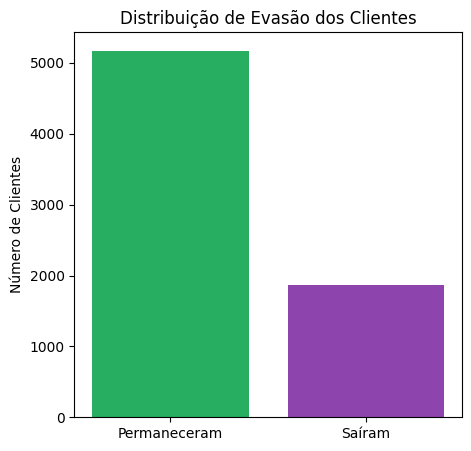

In [ ]:
import matplotlib.pyplot as plt

contagem_evasao = df['Evasao'].value_counts()

plt.figure(figsize=(5,5))
plt.bar(contagem_evasao.index, contagem_evasao.values, color=['#27ae60','#8e44ad'])
plt.xticks([0,1], ['Permaneceram', 'Saíram'])
plt.ylabel('Número de Clientes')
plt.title('Distribuição de Evasão dos Clientes')
plt.savefig("Gráfico1.png")
plt.show()

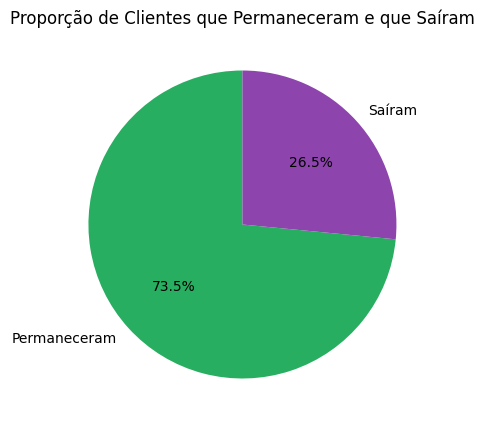

In [ ]:
plt.figure(figsize=(5,5))
plt.pie(contagem_evasao.values, labels=['Permaneceram', 'Saíram'], autopct='%1.1f%%', startangle=90, colors=['#27ae60','#8e44ad'])
plt.title('Proporção de Clientes que Permaneceram e que Saíram')
plt.savefig("Gráfico2.png")
plt.show()

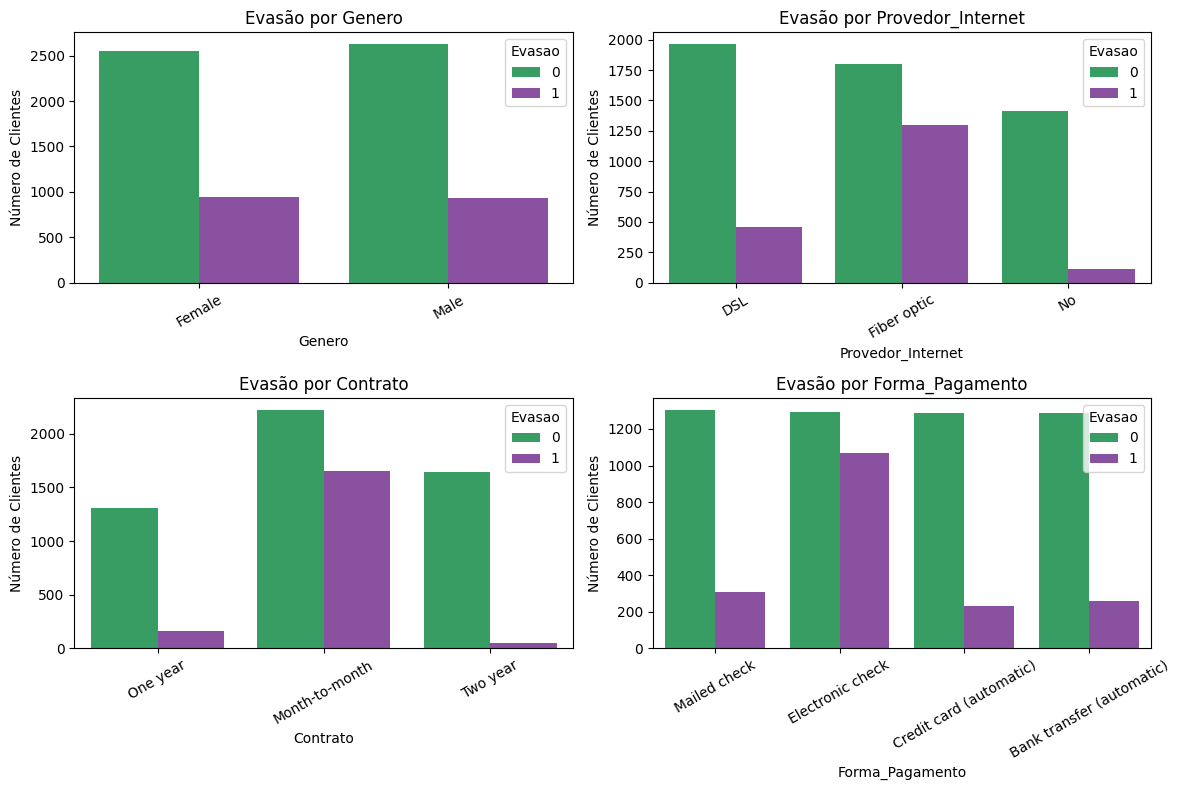

In [ ]:
import seaborn as sns

colunas_categoricas1 = ["Genero", "Provedor_Internet", "Contrato", "Forma_Pagamento"]
n_cols = 2
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas1):
    sns.countplot(
        x=col,
        hue="Evasao",
        data=df,
        palette=["#27ae60", "#8e44ad"],
        ax=axes[i]
    )
    axes[i].set_title(f"Evasão por {col}")
    axes[i].set_ylabel("Número de Clientes")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis="x", rotation=30)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.savefig("Gráfico3.png")
plt.tight_layout()
plt.show()



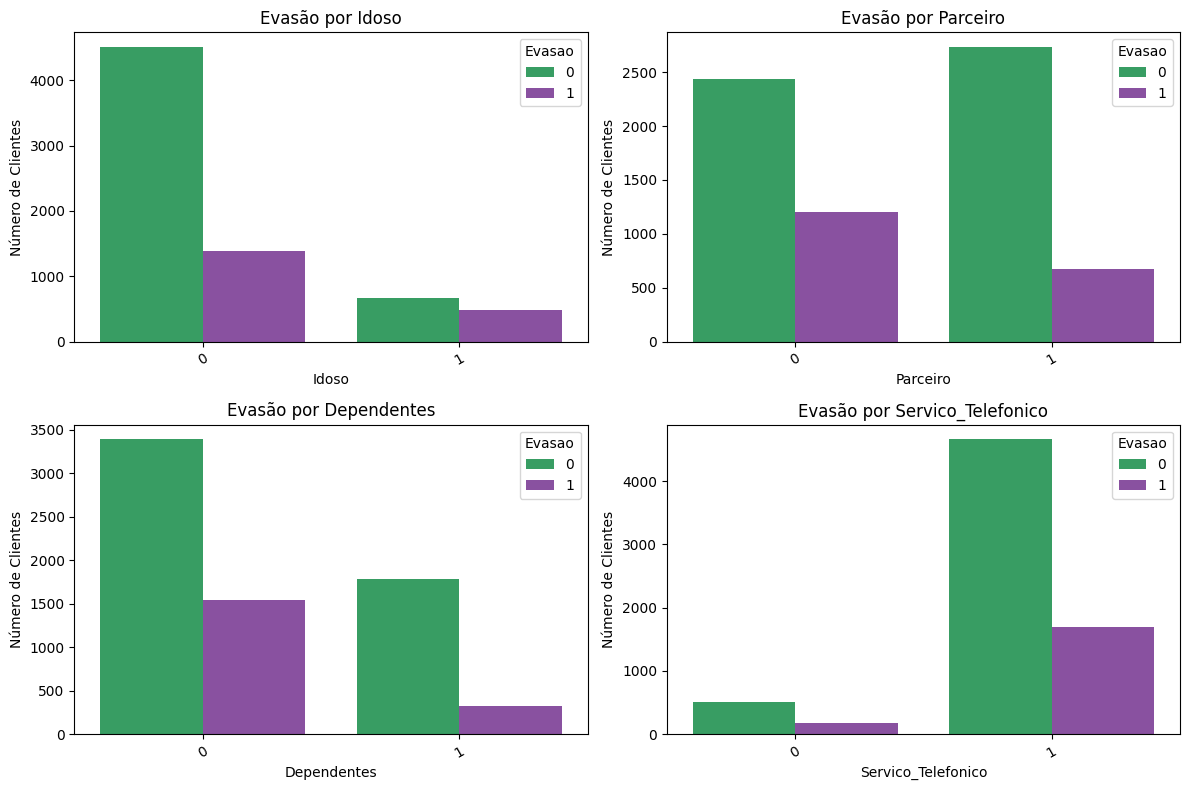

In [ ]:
colunas_categoricas2 = ["Idoso", "Parceiro", "Dependentes", "Servico_Telefonico"]
n_cols = 2
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas2):
    sns.countplot(
        x=col,
        hue="Evasao",
        data=df,
        palette=["#27ae60", "#8e44ad"],
        ax=axes[i]
    )
    axes[i].set_title(f"Evasão por {col}")
    axes[i].set_ylabel("Número de Clientes")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis="x", rotation=30)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.savefig("Gráfico4.png")
plt.tight_layout()
plt.show()

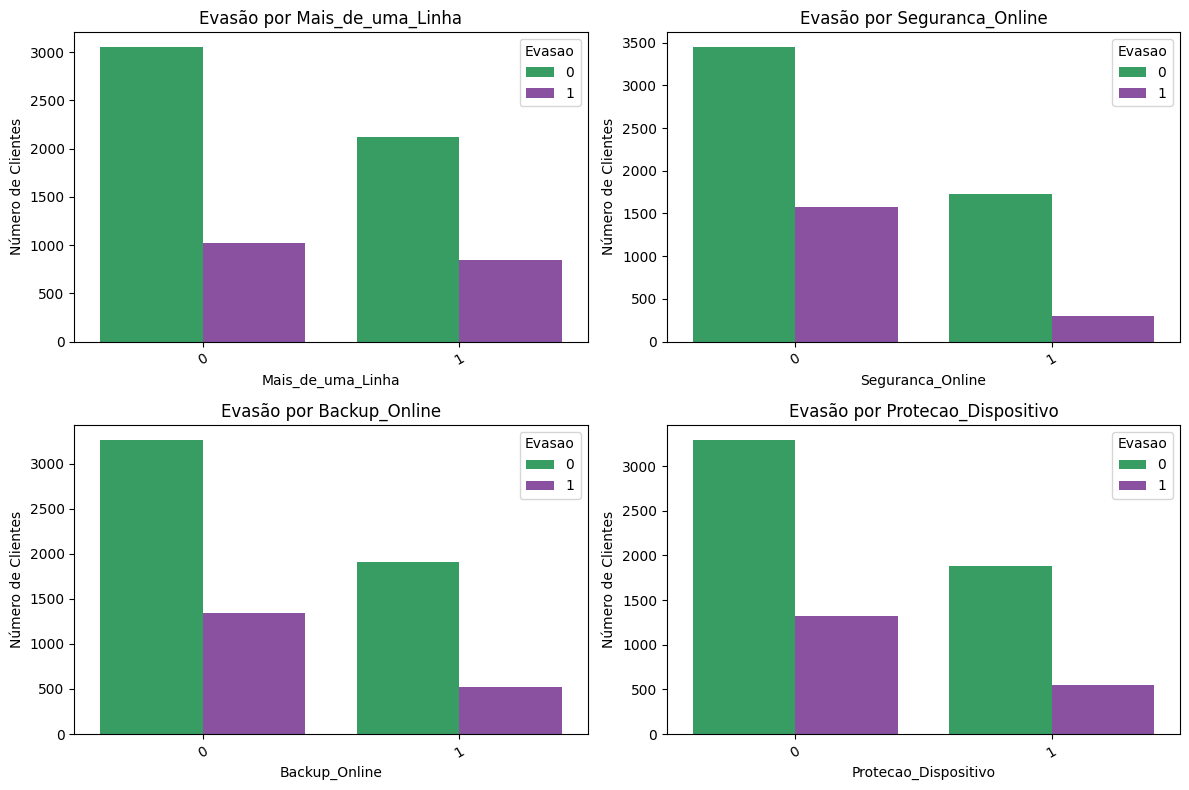

In [ ]:
colunas_categoricas3 = ["Mais_de_uma_Linha", "Seguranca_Online", "Backup_Online", "Protecao_Dispositivo"]
n_cols = 2
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas3):
    sns.countplot(
        x=col,
        hue="Evasao",
        data=df,
        palette=["#27ae60", "#8e44ad"],
        ax=axes[i]
    )
    axes[i].set_title(f"Evasão por {col}")
    axes[i].set_ylabel("Número de Clientes")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis="x", rotation=30)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.savefig("Gráfico5.png")
plt.tight_layout()
plt.show()

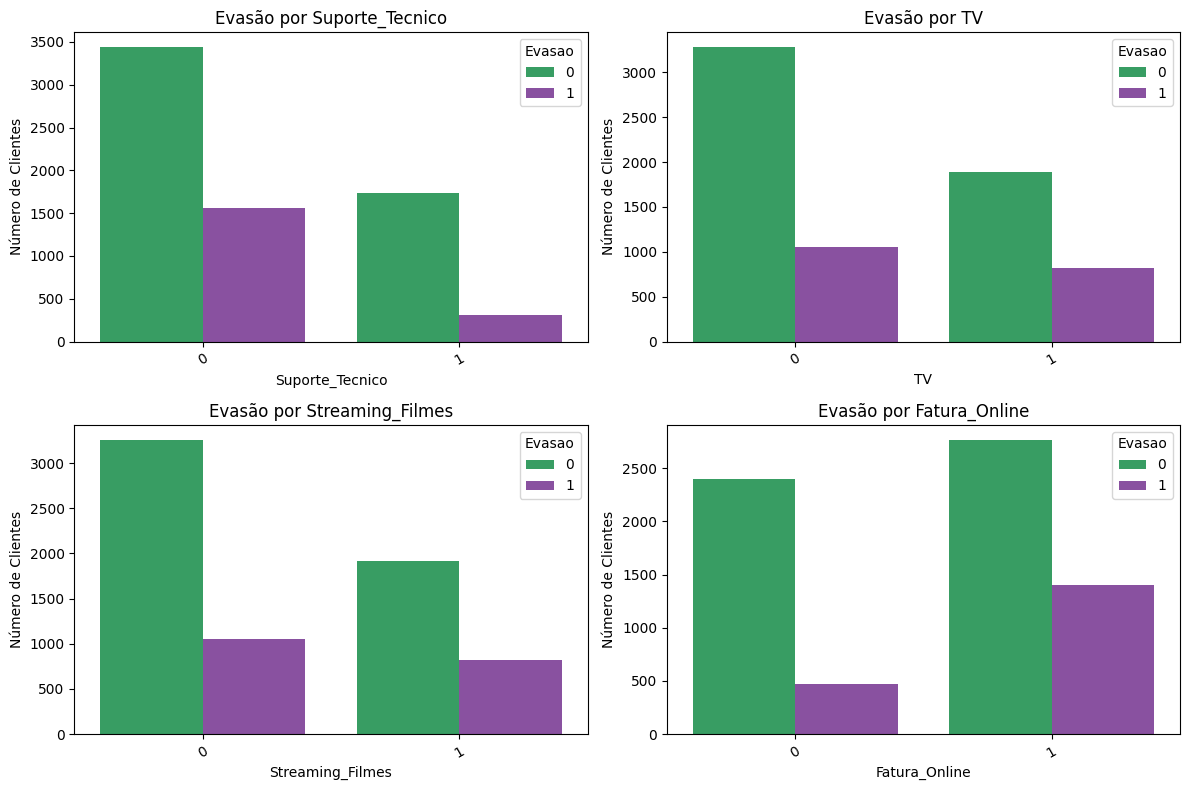

In [ ]:
colunas_categoricas4 = ["Suporte_Tecnico", "TV", "Streaming_Filmes", "Fatura_Online"]
n_cols = 2
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas4):
    sns.countplot(
        x=col,
        hue="Evasao",
        data=df,
        palette=["#27ae60", "#8e44ad"],
        ax=axes[i]
    )
    axes[i].set_title(f"Evasão por {col}")
    axes[i].set_ylabel("Número de Clientes")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis="x", rotation=30)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.savefig("Gráfico6.png")
plt.tight_layout()
plt.show()

In [ ]:
import math
import os

def plotar_numericas(df, colunas, n_cols=2, n_rows=2):

    figuras = []
    blocos = math.ceil(len(colunas) / (n_cols*n_rows))

    for b in range(blocos):
        subset = colunas[b*(n_cols*n_rows):(b+1)*(n_cols*n_rows)]

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
        axes = axes.flatten()

        for i, col in enumerate(subset):
            sns.boxplot(
                x="Evasao",
                y=col,
                hue="Evasao",
                data=df,
                palette=["#27ae60", "#8e44ad"],
                legend=False,
                ax=axes[i]
            )
            axes[i].set_title(f"Evasão vs {col}")
            axes[i].set_xlabel("Evasão (0 = permaneceu, 1 = saiu)")
            axes[i].set_ylabel(col)

        for j in range(len(subset), len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        figuras.append(fig)

    return figuras


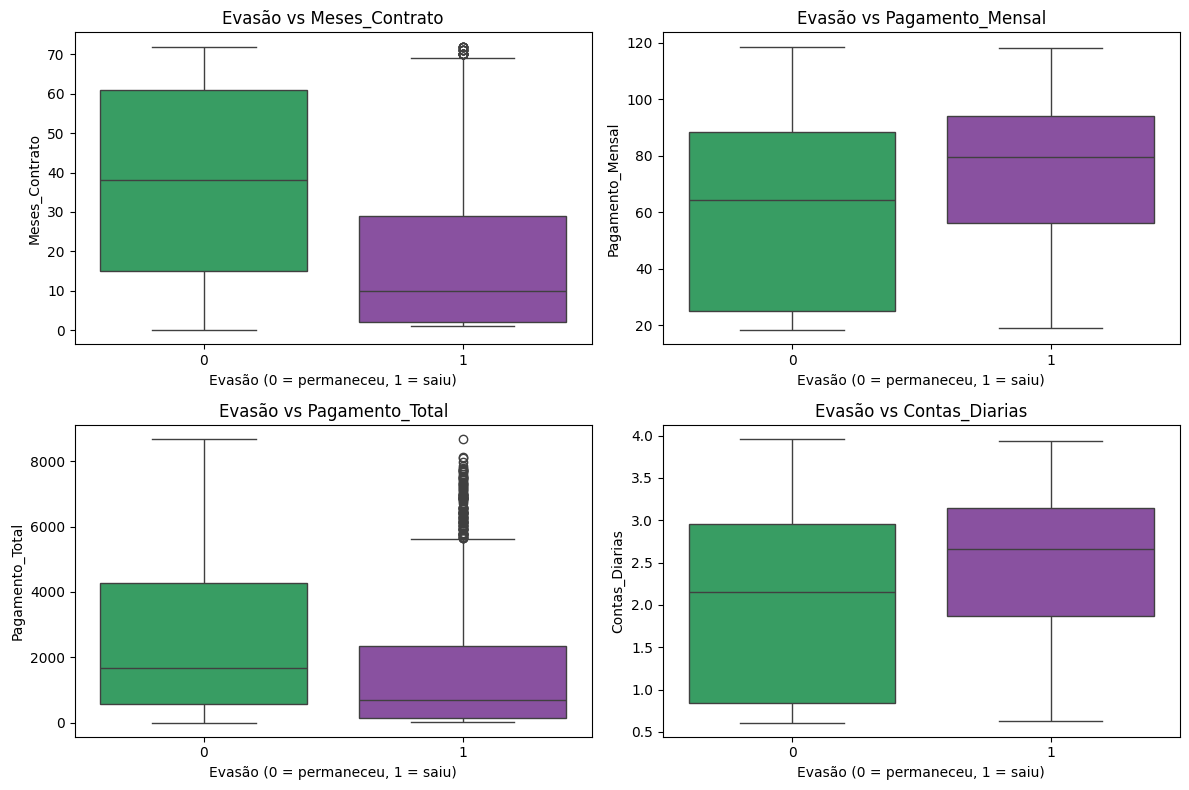

In [ ]:
colunas_numericas = [
    "Meses_Contrato", "Pagamento_Mensal", "Pagamento_Total", "Contas_Diarias"
]

figs_num = plotar_numericas(df, colunas_numericas)

for fig in figs_num:
    plt.show(fig)

#📄Relatorio Final

#Relatório de Análise de Evasão de Clientes (Churn)

##Introdução

Nesta análise, investigamos os fatores associados à evasão de clientes (churn) em um serviço de telecomunicações.
O objetivo é identificar padrões que diferenciem clientes que permanecem dos que cancelam, de forma a orientar ações que reduzam a evasão e aumentem a retenção.
Bibliotecas utilizadas: Pandas, Matplotlib, Seaborn, Numpy, Math e OS.

##Etapa 1: Extração dos dados

Os dados foram extraídos do GitHub, no formato .JSON, e convertidos para um DataFrame utilizando a biblioteca Pandas.

##Etapa 2: Transformação dos dados

Foi realizada uma análise inicial do dataset, verificando os tipos de dados e a sua disposição.
Em seguida, ocorreu a “explosão” dos dicionários, o que permitiu uma melhor organização das variáveis.
Na sequência, as categorias únicas foram analisadas para identificar possíveis inconsistências.

Quanto à limpeza dos dados, foram tratados valores nulos, strings vazias e linhas duplicadas. Apenas a coluna Churn apresentou problema: 224 strings vazias. Como o dataset contém 7.267 linhas, isso representa cerca de 3% dos dados. Esse valor foi considerado irrelevante e, portanto, as linhas foram removidas. Além disso, a coluna de ID também foi descartada por não ter relevância analítica.

Para garantir consistência, foi garantido que não houvesse strings com espaços incorretos, e algumas colunas tiveram seus tipos ajustados (por exemplo, valores numéricos convertidos para float).
Adicionalmente, foi criada a coluna Contas_Diárias, de modo a enriquecer a análise.

Por fim, as variáveis categóricas foram padronizadas, substituindo “Sim/Não” por “1/0”.
Com todas essas transformações, o dataset estava devidamente preparado para a fase de análise.

##Etapa 3: Carga e análise dos dados

Com df.describe(), foi possível ter uma visão geral do dataset. Identificamos que a empresa apresenta uma taxa de evasão aproximada de 26%, além de outros padrões discutidos a seguir.

###Gráficos iniciais

Gráfico de barras: oferece uma visão geral das proporções de evasão.

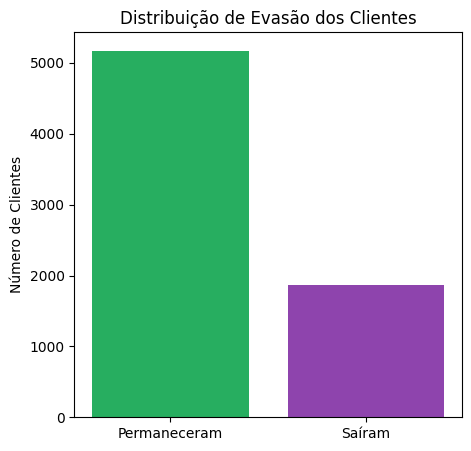


Gráfico de pizza: facilita a visualização das mesmas proporções de forma mais clara.

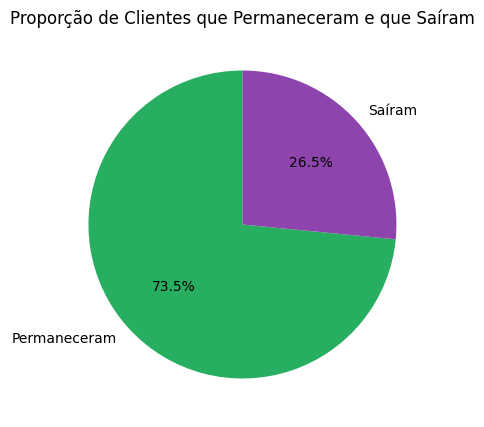

###Análise por Categorias

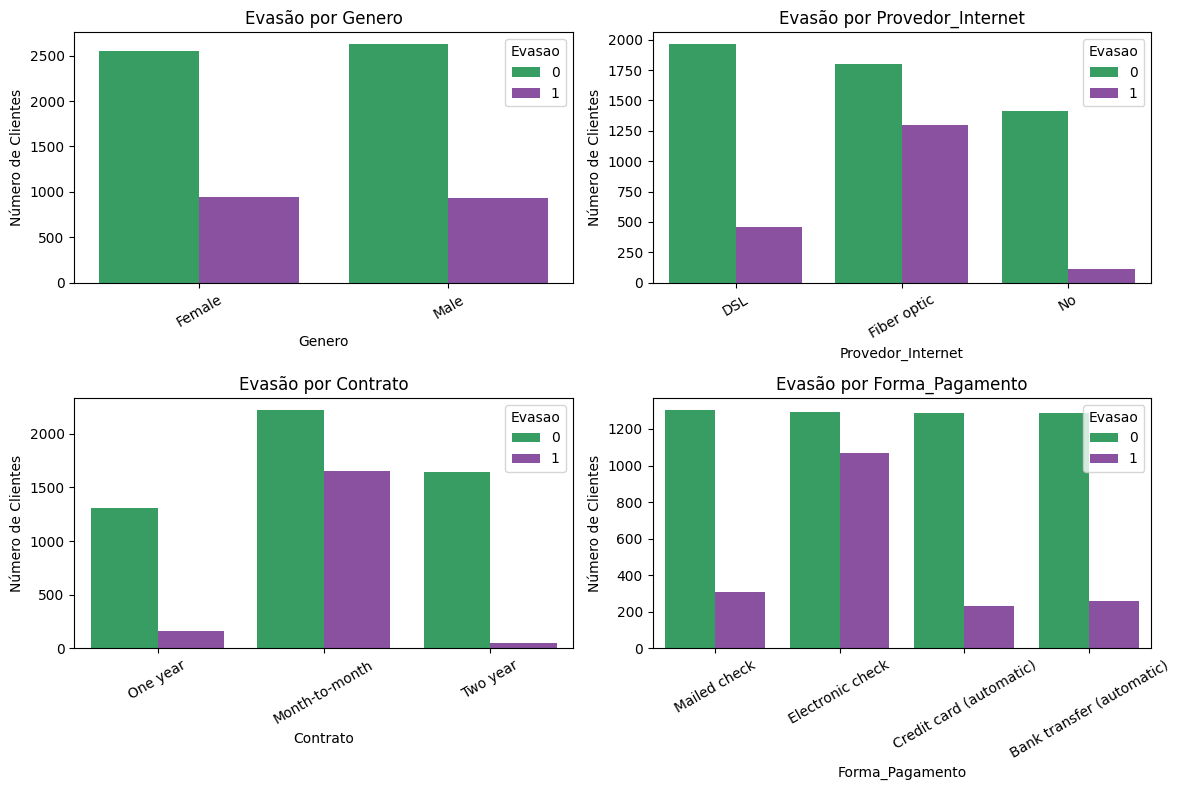

####Evasão por Idoso

Clientes idosos apresentam taxa de evasão proporcionalmente mais alta.
Em números absolutos, a maioria dos cancelamentos ocorre entre não idosos, que representam a maior parte da base. Ou seja, ser idoso aumenta o risco de churn.

####Evasão por Parceiro

Clientes sem parceiro têm taxa de evasão mais elevada. Clientes com parceiro demonstram maior retenção. Ou seja, ter parceiro contribui para reduzir o churn.

####Evasão por Dependentes

Clientes sem dependentes apresentam mais cancelamentos. Clientes com dependentes cancelam menos. Ou seja, ter dependentes é um fator de retenção.

####Evasão por Serviço Telefônico

A maioria das evasões ocorre entre clientes que possuem serviço telefônico.
Proporcionalmente, clientes sem telefone também apresentam churn considerável.Ou seja, o serviço telefônico não reduz evasão, podendo ser percebido como básico e de pouco valor agregado.

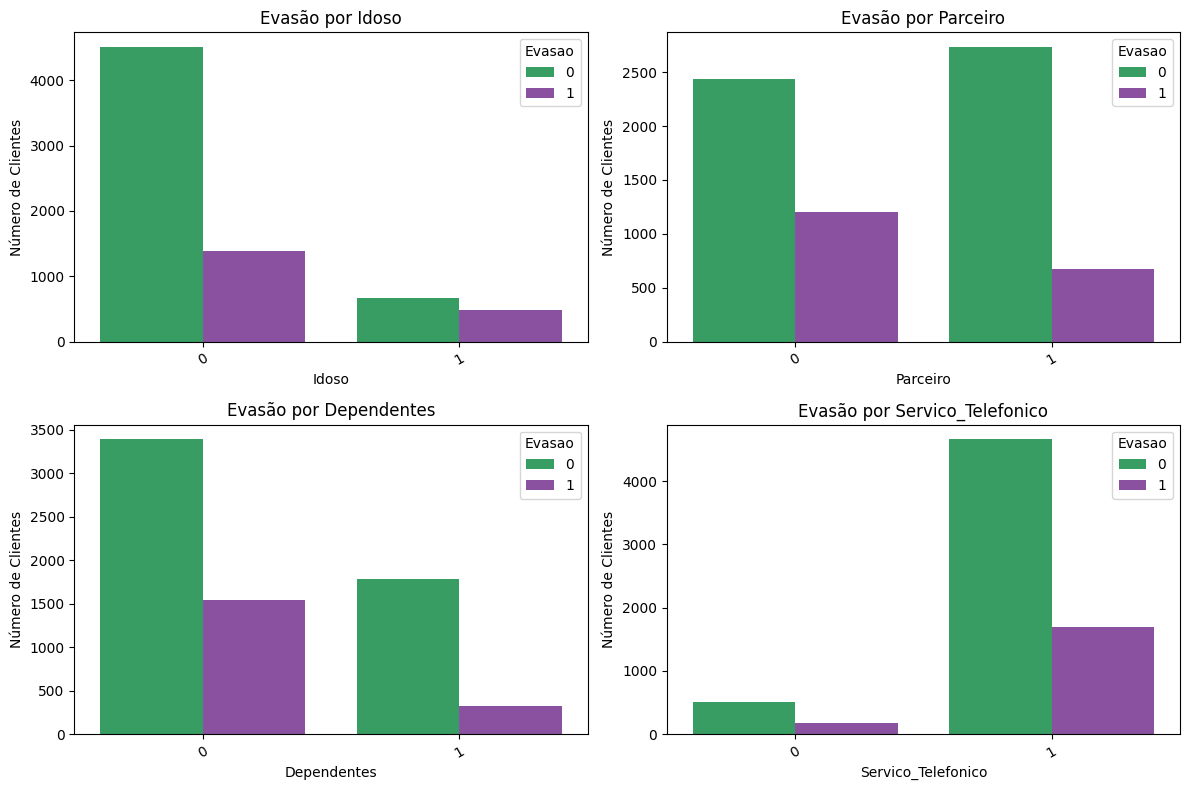

####Evasão por Mais de uma Linha

Clientes com apenas uma linha apresentam maior número de cancelamentos.Clientes com mais de uma linha também cancelam, mas em menor volume. Ou seja, ter mais de uma linha não garante retenção, mas quem tem apenas uma linha cancela mais.

####Evasão por Segurança Online

Clientes sem segurança online cancelam mais.Clientes com segurança online apresentam churn significativamente menor. Ou seja, a segurança online ajuda na retenção.

####Evasão por Backup Online

Clientes sem backup online apresentam taxa de evasão mais alta. Clientes com backup online cancelam menos. Ou seja, o backup online reduz churn.

####Evasão por Proteção de Dispositivo

Clientes sem proteção de dispositivo apresentam maior evasão. Clientes com proteção de dispositivo cancelam menos.Ou seja, serviços de proteção contribuem para manter o cliente.

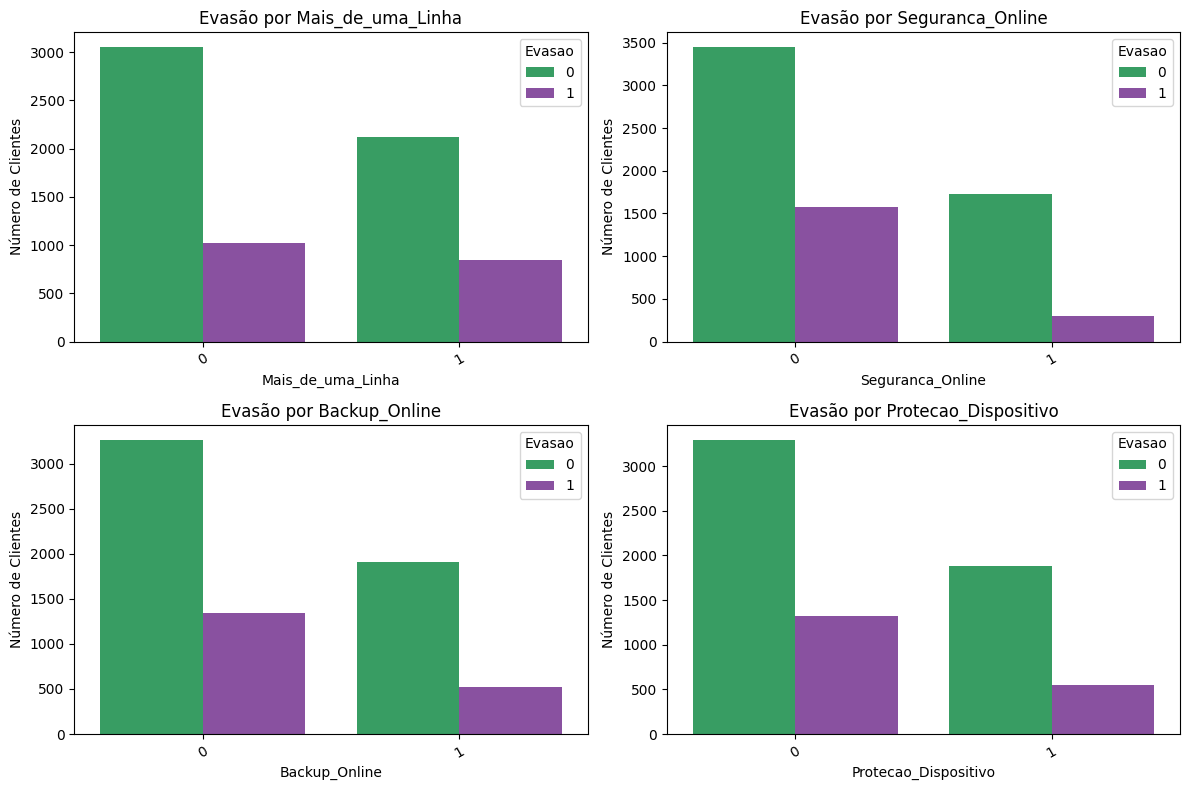

####Evasão por Suporte Técnico

Clientes sem suporte técnico cancelam mais.Clientes com suporte técnico têm churn reduzido. Ou seja, o suporte técnico é um forte fator de retenção.

####Evasão por TV

Clientes sem TV apresentam mais cancelamentos. Clientes com TV cancelam menos, mas ainda em volume relevante. Ou seja, a TV contribui para reter clientes, mas não é decisiva.

####Evasão por Streaming de Filmes

Clientes sem streaming de filmes têm evasão mais alta. Clientes com streaming cancelam menos.Ou seja, serviços de entretenimento ajudam na retenção.

####Evasão por Fatura Online

Clientes com fatura online apresentam maior número de evasões. Clientes sem fatura online cancelam menos proporcionalmente.
Ou seja, a fatura online está associada a maior churn, talvez por estar ligada a clientes mais digitais e propensos a trocar de provedor.

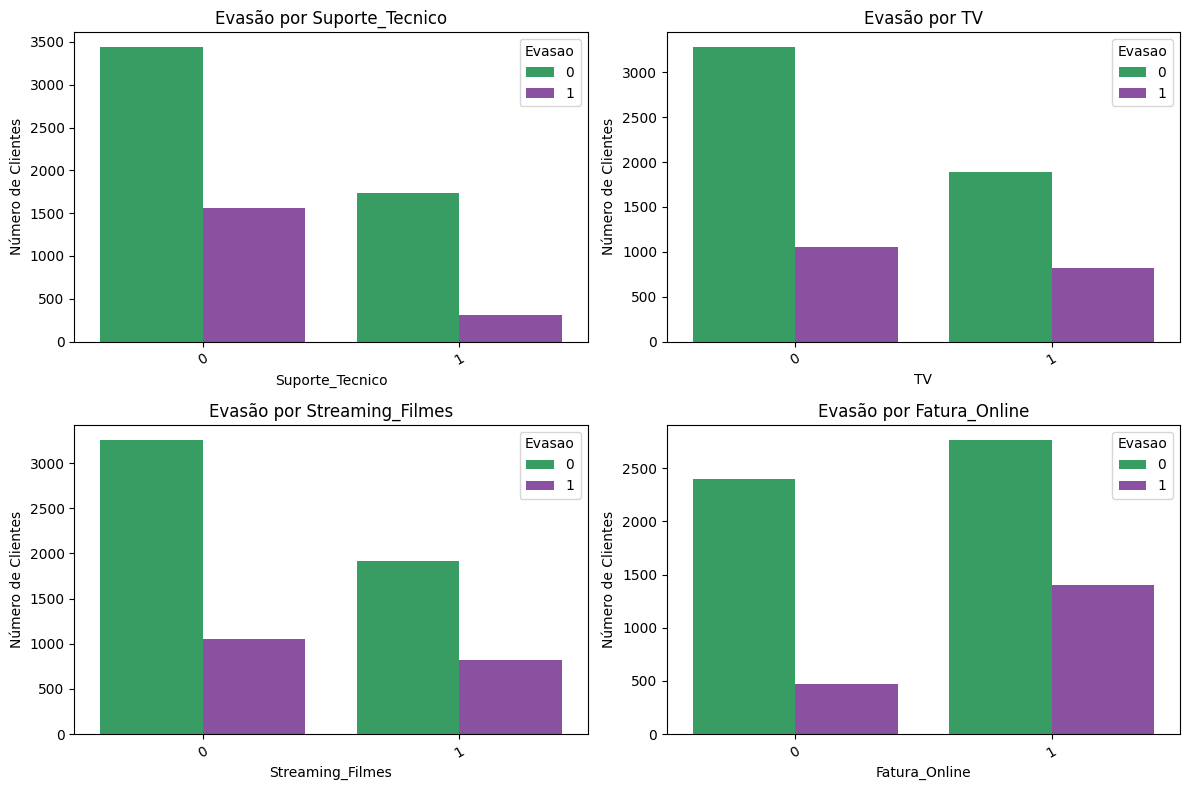

####Evasão por Contrato

Clientes com contrato mensal apresentam a taxa de evasão mais alta.Clientes com contratos anuais ou bianuais cancelam em menor proporção.Ou seja, contratos de longo prazo aumentam a retenção.

####Evasão por Forma de Pagamento

Clientes que pagam via boleto bancário ou cartão manual apresentam mais cancelamentos. Clientes que utilizam débito automático cancelam significativamente menos. Ou seja, formas de pagamento automáticas reduzem churn, pois diminuem atritos no processo.

####Evasão por Cobrança Eletrônica

Clientes que recebem cobrança eletrônica apresentam maior taxa de evasão.Clientes com métodos tradicionais de cobrança cancelam menos.Ou seja, cobrança eletrônica pode estar relacionada a clientes mais digitais, que tendem a trocar de provedor com maior facilidade.

####Evasão por Valor Mensal

Clientes com mensalidades mais baixas cancelam menos. Clientes com mensalidades mais altas apresentam churn mais elevado. Ou seja, quanto maior o valor da mensalidade, maior o risco de evasão, indicando sensibilidade ao preço.

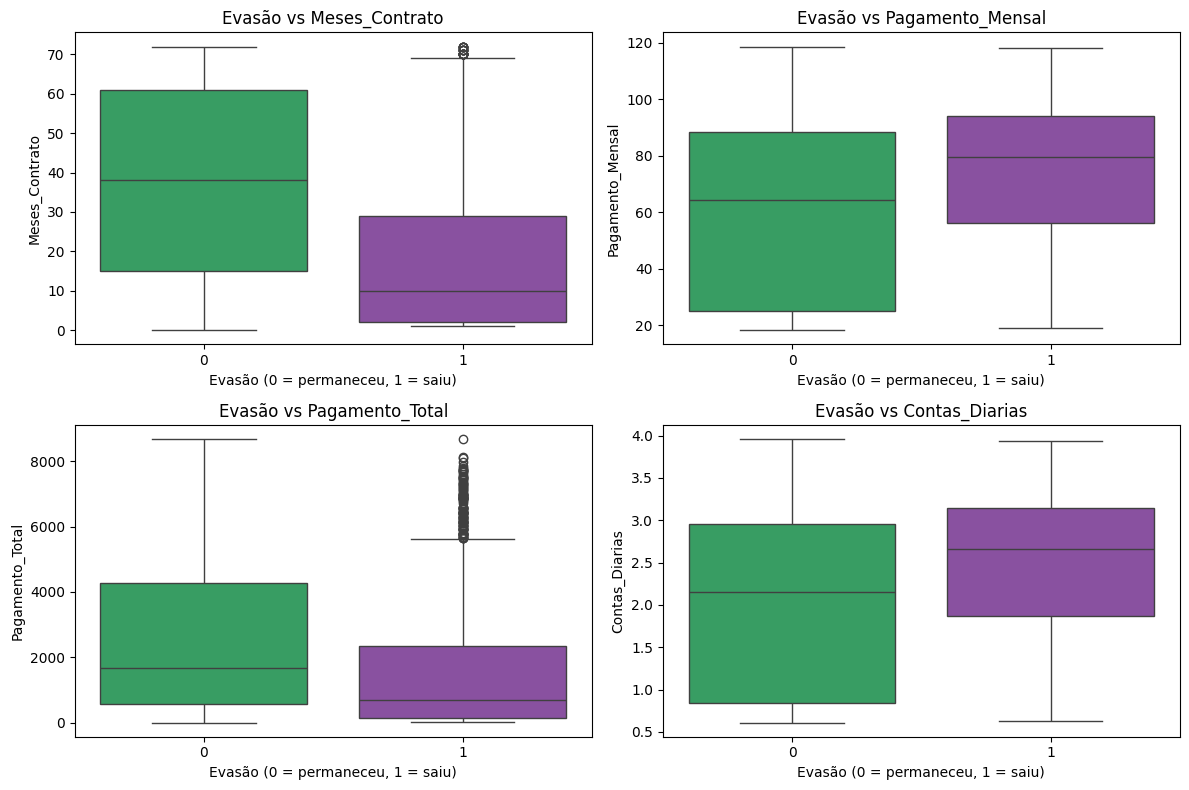

####Evasão por Meses de Contrato

Clientes que permaneceram têm, em média, contratos mais longos. Clientes que saíram apresentam contratos curtos, concentrados nos primeiros meses Ou seja, a fidelização acontece após os primeiros meses, sendo a fase inicial a mais crítica para o churn.

####Evasão por Pagamento Mensal

Clientes com valores mensais mais altos têm maior taxa de evasão. Clientes com mensalidades mais baixas apresentam churn reduzido. Ou seja, há sensibilidade ao preço: quanto maior o valor da mensalidade, maior o risco de evasão.

####Evasão por Pagamento Total

Clientes que permaneceram têm um pagamento total acumulado muito maior, reflexo da sua permanência. Clientes que saíram, em média, contribuíram pouco financeiramente antes do cancelamento. Ou seja, clientes que geram maior valor ao longo do tempo tendem a ser mais fiéis.

####Evasão por Contas Diárias

Clientes que saíram possuem contas diárias ligeiramente mais altas em relação aos que permaneceram. Isso pode indicar maior carga de cobrança ou percepção de custo. Ou seja, contas mais elevadas no dia a dia estão associadas a maior risco de churn.

##Conclusões Finais

###Perfil Demográfico e Social

Idosos apresentam maior propensão ao churn e ter parceiro e dependentes é fator de retenção.

###Serviços Contratados

Serviços adicionais (segurança online, backup, proteção, suporte técnico, streaming) reduzem a evasão.

Serviços considerados básicos (telefone, fatura online) não contribuem para retenção e, em alguns casos, estão associados a maior churn.

###Contrato e Pagamento

Contratos mensais têm maior risco de evasão, enquanto contratos de longo prazo retêm mais clientes. Pagamento automático reduz churn, enquanto boleto/cartão manual aumentam. Além disso, clientes com mensalidades altas cancelam mais, mostrando sensibilidade ao preço.

###Análise Numérica

Clientes que saem geralmente têm contratos mais curtos e baixo pagamento total acumulado.

A fase inicial é crítica: grande parte do churn ocorre nos primeiros meses.

Valores mensais e contas diárias mais altos aumentam o risco de cancelamento.

## Sugestões

O churn está fortemente ligado à fase inicial do contrato, ao valor da mensalidade e à ausência de serviços adicionais de valor agregado. Portanto, as estratégias de retenção devem priorizar planos de longo prazo,descontos e benefícios nos primeiros meses, serviços digitais de valor agregado e facilitação do pagamento automático.